# Environment Setup

In [ ]:
# 🔧 Core Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime,timedelta
import requests
import os
import time
import io
import zipfile
from math import radians, cos, sin, asin, sqrt

# 🧰 Sklearn libraries
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, AdaBoostClassifier, RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_sample_weight 

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


# Data Acqisition:

In [3]:
print("="*60)
print("📥 STEP 1: DATA ACQUISITION (Explicit Date Range)")
print("="*60)

# ============================================================================
# 1. SPECIFY YOUR EXACT DATE RANGE
# ============================================================================
print("\n 1. DEFINING DATE RANGE")
print("-" * 60)

# 👇 CHANGE THESE DATES TO SPECIFY EXACTLY WHAT YOU WANT TO DOWNLOAD 👇
# Format: datetime(Year, Month, Day)
START_DATE = datetime(2023, 1, 1)  # Start downloading from January 2023
END_DATE = datetime(2024, 1, 1)    # Stop at January 2024 (This will give exactly 12 months)

# Generate a list of the 1st day of every month between the start and end dates
# 'MS' stands for "Month Start"
months_to_fetch = pd.date_range(start=START_DATE, end=END_DATE, freq='MS')

print(f"Start Date: {START_DATE.strftime('%Y-%m')}")
print(f"End Date:   {END_DATE.strftime('%Y-%m')}")
print(f"Total Months to Download: {len(months_to_fetch)}")

# ============================================================================
# 2. BUILD DOWNLOAD LINKS
# ============================================================================
symbol = "BTCUSDT"
interval = "15m"
base_url = f"https://data.binance.vision/data/spot/monthly/klines/{symbol}/{interval}/"

file_list = []
for date in months_to_fetch:
    year = date.year
    month = str(date.month).zfill(2)
    filename = f"{symbol}-{interval}-{year}-{month}.zip"
    url = base_url + filename
    file_list.append((filename, url))

print(f"\n📥 Preparing to download {len(file_list)} monthly zip files...")

# ============================================================================
# 3. DOWNLOAD AND EXTRACT
# ============================================================================
all_dataframes = []

for filename, url in file_list:
    try:
        print(f"  Fetching: {filename}...", end=" ")
        response = requests.get(url)
        response.raise_for_status()
        
        with zipfile.ZipFile(io.BytesIO(response.content)) as zip_file:
            csv_filename = zip_file.namelist()[0]
            with zip_file.open(csv_filename) as csv_file:
                df = pd.read_csv(csv_file, header=None)
        
        df.columns = [
            'open_time', 'open', 'high', 'low', 'close', 'volume',
            'close_time', 'quote_asset_volume', 'number_of_trades',
            'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore'
        ]
        
        # --- TIMESTAMP MAGNITUDE FIX ---
        df['open_time'] = pd.to_numeric(df['open_time'], errors='coerce')
        first_valid_ts = df['open_time'].dropna().iloc[0]
        
        if first_valid_ts > 1e14:
            df['open_time'] = pd.to_datetime(df['open_time'], unit='us')
        else:
            df['open_time'] = pd.to_datetime(df['open_time'], unit='ms')
        # ---------------------------------

        all_dataframes.append(df)
        print("✅")
        
    except requests.exceptions.HTTPError:
        print("⚠️ Not found, skipping.")
    except zipfile.BadZipFile:
        print("⚠️ Corrupted zip, skipping.")

# ============================================================================
# 4. COMBINE AND CLEAN
# ============================================================================
if all_dataframes:
    print("\n🔗 Combining and sorting data...")
    df_raw = pd.concat(all_dataframes, ignore_index=True)
    
    numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'taker_buy_base_asset_volume']
    df_raw[numeric_cols] = df_raw[numeric_cols].astype(float)

    df_raw = df_raw.sort_values('open_time').drop_duplicates(subset=['open_time']).reset_index(drop=True)

    print("\n" + "="*60)
    print("✅ DATA ACQUISITION COMPLETE")
    print("="*60)
    print(f"Total Rows:      {len(df_raw):,}")
    print(f"Date Range:      {df_raw['open_time'].min()} to {df_raw['open_time'].max()}")
    print(f"Memory Usage:    {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print("="*60)
else:
    print("\n❌ ERROR: No data was downloaded.")

📥 STEP 1: DATA ACQUISITION (Explicit Date Range)

 1. DEFINING DATE RANGE
------------------------------------------------------------
Start Date: 2023-01
End Date:   2024-01
Total Months to Download: 13

📥 Preparing to download 13 monthly zip files...
  Fetching: BTCUSDT-15m-2023-01.zip... ✅
  Fetching: BTCUSDT-15m-2023-02.zip... ✅
  Fetching: BTCUSDT-15m-2023-03.zip... ✅
  Fetching: BTCUSDT-15m-2023-04.zip... ✅
  Fetching: BTCUSDT-15m-2023-05.zip... ✅
  Fetching: BTCUSDT-15m-2023-06.zip... ✅
  Fetching: BTCUSDT-15m-2023-07.zip... ✅
  Fetching: BTCUSDT-15m-2023-08.zip... ✅
  Fetching: BTCUSDT-15m-2023-09.zip... ✅
  Fetching: BTCUSDT-15m-2023-10.zip... ✅
  Fetching: BTCUSDT-15m-2023-11.zip... ✅
  Fetching: BTCUSDT-15m-2023-12.zip... ✅
  Fetching: BTCUSDT-15m-2024-01.zip... ✅

🔗 Combining and sorting data...

✅ DATA ACQUISITION COMPLETE
Total Rows:      38,011
Date Range:      2023-01-01 00:00:00 to 2024-01-31 23:45:00
Memory Usage:    3.48 MB


# Exploratory Data Analysis:

In [4]:
print("="*60)
print("🔄 STEP 2: ETL - General Structure, Missing Values, Duplicates")
print("="*60)

# Assuming 'df_raw' is the dataframe we got from Step 1 (Data Acquiring)
# If you are running this in a new session, you would load it here. 
# For now, we assume df_raw is in memory.

# ============================================================================
# 1. GENERAL STRUCTURE & DATA TYPES
# ============================================================================
print("\n 1. GENERAL STRUCTURE")
print("-" * 60)
print(f"DataFrame Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print("\nColumn Names:")
print(df_raw.columns.tolist())
print("\nData Types:")
print(df_raw.dtypes)

# ============================================================================
# 2. MISSING VALUES CHECK
# ============================================================================
print("\n 2. MISSING VALUES")
print("-" * 60)
missing_values = df_raw.isnull().sum()
missing_pct = (missing_values / len(df_raw)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing %': missing_pct.round(2)
})

# Filter to show only columns with missing values
missing_summary = missing_df[missing_df['Missing Count'] > 0]
if missing_summary.empty:
    print("✅ No missing values found in any column.")
else:
    print("⚠️ Missing values detected:")
    print(missing_summary)

# ============================================================================
# 3. DUPLICATE CHECK
# ============================================================================
print("\n 3. DUPLICATE CHECK")
print("-" * 60)
# Check for exact duplicate rows
exact_duplicates = df_raw.duplicated().sum()
print(f"Exact duplicate rows: {exact_duplicates}")

# Check for duplicate timestamps (critical for time series)
time_duplicates = df_raw.duplicated(subset=['open_time']).sum()
print(f"Duplicate timestamps: {time_duplicates}")

if time_duplicates > 0:
    print("\n⚠️ Sample of duplicate timestamps:")
    print(df_raw[df_raw.duplicated(subset=['open_time'], keep=False)][['open_time', 'open', 'close']].head())

# ============================================================================
# 4. BASIC DATA TYPE VALIDATION (Transform)
# ============================================================================
print("\n 4. DATA TYPE VALIDATION")
print("-" * 60)
# Ensure open_time is datetime
if not pd.api.types.is_datetime64_any_dtype(df_raw['open_time']):
    print("⚠️ 'open_time' is not datetime. Converting...")
    df_raw['open_time'] = pd.to_datetime(df_raw['open_time'], unit='ms')
else:
    print("✅ 'open_time' is correctly formatted as datetime.")

# Ensure price and volume columns are numeric
numeric_cols = ['open', 'high', 'low', 'close', 'volume', 'taker_buy_base_asset_volume']
for col in numeric_cols:
    if not pd.api.types.is_numeric_dtype(df_raw[col]):
        print(f"⚠️ '{col}' is not numeric. Converting to float...")
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print("✅ All core columns validated for correct data types.")

# ============================================================================
# 5. LOAD (Save to disk for reproducibility)
# ============================================================================
print("\n 5. SAVE PROCESSED RAW DATA (LOAD)")
print("-" * 60)

# Create a data directory if it doesn't exist
os.makedirs('data/raw', exist_ok=True)

# Save as Parquet (faster and smaller than CSV, preserves data types perfectly)
output_path = 'data/raw/btcusdt_15m_etl.parquet'
df_raw.to_parquet(output_path, index=False)
print(f"✅ Data successfully saved to: {output_path}")
print(f"   File size: {os.path.getsize(output_path) / 1024:.2f} KB")

print("\n" + "="*60)
print("✅ STEP 2 COMPLETE: ETL Finished.")
print("="*60)

display(df_raw.head())

🔄 STEP 2: ETL - General Structure, Missing Values, Duplicates

 1. GENERAL STRUCTURE
------------------------------------------------------------
DataFrame Shape: 38,011 rows, 12 columns

Column Names:
['open_time', 'open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore']

Data Types:
open_time                       datetime64[ms]
open                                   float64
high                                   float64
low                                    float64
close                                  float64
volume                                 float64
close_time                               int64
quote_asset_volume                     float64
number_of_trades                         int64
taker_buy_base_asset_volume            float64
taker_buy_quote_asset_volume           float64
ignore                                   int64
dtype: object

 2. MISSING VALUES
--

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_asset_volume,taker_buy_quote_asset_volume,ignore
0,2023-01-01 00:00:00,16541.77,16544.76,16520.00,16520.69,1172.53835,1672532099999,1.938455e+07,37484,553.35053,9.148050e+06,0
1,2023-01-01 00:15:00,16521.26,16545.70,16517.72,16544.19,1102.62888,1672532999999,1.822982e+07,33528,588.35947,9.727375e+06,0
2,2023-01-01 00:30:00,16544.19,16544.61,16508.39,16515.43,1365.65633,1672533899999,2.256529e+07,48518,664.46239,1.097913e+07,0
3,2023-01-01 00:45:00,16515.91,16536.84,16515.43,16529.67,724.01214,1672534799999,1.196664e+07,30324,373.77533,6.177796e+06,0
4,2023-01-01 01:00:00,16529.59,16541.80,16525.78,16538.21,977.24680,1672535699999,1.615868e+07,32200,458.02292,7.573419e+06,0


# Data Cleaning

In [36]:
print("="*60)
print("🧹 STEP 3: Data Cleaning (Strictly No Data Leakage)")
print("="*60)

# 1. Load the ETL data from Step 2
# (Adjust the extension if you saved as CSV instead of Parquet)
try:
    df_clean = pd.read_parquet('data/raw/btcusdt_15m_etl.parquet')
except FileNotFoundError:
    df_clean = pd.read_csv('data/raw/btcusdt_15m_etl.csv', parse_dates=['open_time'])

print(f"Loaded {len(df_clean):,} rows for cleaning.")

# ============================================================================
# 2. ENSURE CHRONOLOGICAL ORDER
# ============================================================================
print("\n 1. ENSURING CHRONOLOGICAL ORDER")
print("-" * 60)
# Time series MUST be sorted oldest to newest before any cleaning
df_clean = df_clean.sort_values('open_time').reset_index(drop=True)
print("✅ Data sorted by 'open_time'.")

# ============================================================================
# 3. DROP DUPLICATES (No Leakage)
# ============================================================================
print("\n 2. DROPPING DUPLICATES")
print("-" * 60)
initial_rows = len(df_clean)
# Drop rows with the exact same timestamp. Keep the first one.
df_clean = df_clean.drop_duplicates(subset=['open_time'], keep='first')
print(f"Dropped {initial_rows - len(df_clean)} duplicate timestamps.")

# ============================================================================
# 4. HANDLE MISSING VALUES (NO LEAKAGE)
# ============================================================================
print("\n 3. HANDLING MISSING VALUES (Forward Fill)")
print("-" * 60)

# Define the core columns that cannot have missing values
core_cols = ['open', 'high', 'low', 'close', 'volume', 'taker_buy_base_asset_volume']

# --- THE NO LEAKAGE RULE ---
# We DO NOT use df_clean['close'].mean() to fill missing values. 
# That would use future data to fix past data (Leakage!).
# Instead, we use Forward Fill (ffill). If a price is missing, we assume 
# it stayed at the last known price. This only looks backward in time.

missing_before = df_clean[core_cols].isnull().sum().sum()

# Forward fill missing values
df_clean[core_cols] = df_clean[core_cols].ffill()

# Edge case: If the very first row has NaNs, ffill can't fix it (there is no past).
# We safely drop those specific rows.
df_clean = df_clean.dropna(subset=core_cols)

missing_after = df_clean[core_cols].isnull().sum().sum()

print(f"Missing values before: {missing_before}")
print(f"Missing values after:  {missing_after}")
print("✅ Used Forward Fill (ffill) to prevent data leakage.")

# ============================================================================
# 5. HANDLE OUTLIERS (Wait for Step 4/5)
# ============================================================================
print("\n 4. OUTLIER HANDLING")
print("-" * 60)
print("⚠️ Skipping outlier clipping/dropping for now.")
print("Reason: In crypto, massive spikes (flash crashes/pumps) are real market events.")
print("Dropping them now would create artificial gaps in the time series.")
print("We will let the ML model handle them, or handle them AFTER the train/test split.")

# ============================================================================
# 6. SAVE CLEANED DATA
# ============================================================================
print("\n 5. SAVE CLEANED DATA")
print("-" * 60)

os.makedirs('data/processed', exist_ok=True)

try:
    output_path = 'data/processed/btcusdt_15m_clean.parquet'
    df_clean.to_parquet(output_path, index=False)
    print(f"✅ Cleaned data saved to: {output_path}")
except ImportError:
    output_path = 'data/processed/btcusdt_15m_clean.csv'
    df_clean.to_csv(output_path, index=False)
    print(f"✅ Cleaned data saved to: {output_path}")

print(f"Final dataset shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")

print("\n" + "="*60)
print("✅ STEP 3 COMPLETE: Data Cleaning Finished (No Leakage).")
print("="*60)

🧹 STEP 3: Data Cleaning (Strictly No Data Leakage)
Loaded 38,011 rows for cleaning.

 1. ENSURING CHRONOLOGICAL ORDER
------------------------------------------------------------
✅ Data sorted by 'open_time'.

 2. DROPPING DUPLICATES
------------------------------------------------------------
Dropped 0 duplicate timestamps.

 3. HANDLING MISSING VALUES (Forward Fill)
------------------------------------------------------------
Missing values before: 0
Missing values after:  0
✅ Used Forward Fill (ffill) to prevent data leakage.

 4. OUTLIER HANDLING
------------------------------------------------------------
⚠️ Skipping outlier clipping/dropping for now.
Reason: In crypto, massive spikes (flash crashes/pumps) are real market events.
Dropping them now would create artificial gaps in the time series.
We will let the ML model handle them, or handle them AFTER the train/test split.

 5. SAVE CLEANED DATA
------------------------------------------------------------
✅ Cleaned data saved to

# Chronological(based on time) Train/Test/Eval Split

In [37]:
print("="*60)
print("✂️ STEP 4: Chronological Data Splitting (No Leakage)")
print("="*60)

# 1. Load the cleaned data from Step 3
try:
    df_clean = pd.read_parquet('data/processed/btcusdt_15m_clean.parquet')
except FileNotFoundError:
    df_clean = pd.read_csv('data/processed/btcusdt_15m_clean.csv', parse_dates=['open_time'])

print(f"Loaded {len(df_clean):,} rows for splitting.")

# ============================================================================
# 2. DEFINE SPLIT RATIOS
# ============================================================================
print("\n 1. DEFINING SPLIT RATIOS")
print("-" * 60)
# Standard time-series split: 80% Train, 10% Validation, 10% Test
train_ratio = 0.80
val_ratio = 0.10
test_ratio = 0.10

total_rows = len(df_clean)

# Calculate the exact row indices for the splits
train_end_idx = int(total_rows * train_ratio)
val_end_idx = int(total_rows * (train_ratio + val_ratio))

print(f"Total rows: {total_rows:,}")
print(f"Train rows: {train_end_idx:,} (0 to {train_end_idx})")
print(f"Val rows:   {val_end_idx - train_end_idx:,} ({train_end_idx} to {val_end_idx})")
print(f"Test rows:  {total_rows - val_end_idx:,} ({val_end_idx} to end)")

# ============================================================================
# 3. PERFORM THE CHRONOLOGICAL SPLIT
# ============================================================================
print("\n 2. SPLITTING DATA")
print("-" * 60)

# Slice the dataframe strictly by row index (which is sorted by time)
df_train = df_clean.iloc[:train_end_idx].copy()
df_val = df_clean.iloc[train_end_idx:val_end_idx].copy()
df_test = df_clean.iloc[val_end_idx:].copy()

# Reset indices so they start at 0 for each set
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("✅ Data successfully sliced chronologically.")

# ============================================================================
# 4. SANITY CHECK (Crucial for Time Series)
# ============================================================================
print("\n 3. SANITY CHECK (Verifying No Overlap & Correct Order)")
print("-" * 60)

def print_set_info(name, df):
    print(f"\n--- {name} SET ---")
    print(f"Rows: {len(df):,}")
    print(f"Start Date: {df['open_time'].min()}")
    print(f"End Date:   {df['open_time'].max()}")
    print(f"Avg Price:  ${df['close'].mean():,.2f}")

print_set_info("TRAIN", df_train)
print_set_info("VALIDATION", df_val)
print_set_info("TEST", df_test)

# Verify no time overlap
assert df_train['open_time'].max() < df_val['open_time'].min(), " ERROR: Train and Val overlap!"
assert df_val['open_time'].max() < df_test['open_time'].min(), "❌ ERROR: Val and Test overlap!"
print("\n✅ Time overlap check passed. No leakage detected.")

# ============================================================================
# 5. SAVE SPLITS TO DISK
# ============================================================================
print("\n 4. SAVING SPLITS")
print("-" * 60)

os.makedirs('data/splits', exist_ok=True)

try:
    df_train.to_parquet('data/splits/train.parquet', index=False)
    df_val.to_parquet('data/splits/val.parquet', index=False)
    df_test.to_parquet('data/splits/test.parquet', index=False)
    print("✅ Splits saved as Parquet files in 'data/splits/'.")
except ImportError:
    df_train.to_csv('data/splits/train.csv', index=False)
    df_val.to_csv('data/splits/val.csv', index=False)
    df_test.to_csv('data/splits/test.csv', index=False)
    print("✅ Splits saved as CSV files in 'data/splits/'.")

print("\n" + "="*60)
print("✅ STEP 4 COMPLETE: Data Splitting Finished.")
print("="*60)

✂️ STEP 4: Chronological Data Splitting (No Leakage)
Loaded 38,011 rows for splitting.

 1. DEFINING SPLIT RATIOS
------------------------------------------------------------
Total rows: 38,011
Train rows: 30,408 (0 to 30408)
Val rows:   3,801 (30408 to 34209)
Test rows:  3,802 (34209 to end)

 2. SPLITTING DATA
------------------------------------------------------------
✅ Data successfully sliced chronologically.

 3. SANITY CHECK (Verifying No Overlap & Correct Order)
------------------------------------------------------------

--- TRAIN SET ---
Rows: 30,408
Start Date: 2023-01-01 00:00:00
End Date:   2023-11-13 19:00:00
Avg Price:  $27,021.70

--- VALIDATION SET ---
Rows: 3,801
Start Date: 2023-11-13 19:15:00
End Date:   2023-12-23 09:15:00
Avg Price:  $40,011.47

--- TEST SET ---
Rows: 3,802
Start Date: 2023-12-23 09:30:00
End Date:   2024-01-31 23:45:00
Avg Price:  $42,911.18

✅ Time overlap check passed. No leakage detected.

 4. SAVING SPLITS
----------------------------------

# Feature Engneering:

In [38]:
print("="*60)
print("⚙️ STEP 5: Feature Engineering & Target Creation")
print("="*60)

# 1. Load the split data from Step 4
print("\n 1. LOADING SPLITS")
print("-" * 60)
df_train = pd.read_parquet('data/splits/train.parquet')
df_val = pd.read_parquet('data/splits/val.parquet')
df_test = pd.read_parquet('data/splits/test.parquet')

# Remember original lengths so we can split them back later
train_len = len(df_train)
val_len = len(df_val)

# Temporarily combine them to calculate rolling features without leakage
df_combined = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f"Combined dataset for feature calculation: {len(df_combined):,} rows")

# ============================================================================
# 2. FEATURE ENGINEERING (The "Lenses")
# ============================================================================
print("\n 2. CALCULATING FEATURES")
print("-" * 60)

# --- A. Returns (Speed) ---
df_combined['return_1'] = df_combined['close'].pct_change(1)
df_combined['return_3'] = df_combined['close'].pct_change(3)

# --- B. Volatility (Chaos) ---
# 10-period rolling standard deviation of the 1-step return
df_combined['volatility_10'] = df_combined['return_1'].rolling(window=10).std()

# --- C. Trend (Direction) ---
# Exponential Moving Averages (gives more weight to recent prices)
df_combined['ema_20'] = df_combined['close'].ewm(span=20, adjust=False).mean()
df_combined['ema_50'] = df_combined['close'].ewm(span=50, adjust=False).mean()

# Distance from EMA (helps model see if price is overextended)
df_combined['dist_from_ema_20'] = (df_combined['close'] - df_combined['ema_20']) / df_combined['ema_20']

# --- D. Momentum (RSI) ---
# Pure Pandas implementation of 14-period RSI
delta = df_combined['close'].diff()
gain = delta.where(delta > 0, 0.0).ewm(alpha=1/14, min_periods=14).mean()
loss = (-delta.where(delta < 0, 0.0)).ewm(alpha=1/14, min_periods=14).mean()
rs = gain / loss
df_combined['rsi_14'] = 100 - (100 / (1 + rs))

# --- E. Volume (Conviction) ---
# Current volume compared to the 20-period average volume
df_combined['volume_sma_20'] = df_combined['volume'].rolling(window=20).mean()
df_combined['volume_ratio'] = df_combined['volume'] / df_combined['volume_sma_20']

print("✅ Features calculated successfully.")

# ============================================================================
# 3. TARGET ENGINEERING (The "Answer Key")
# ============================================================================
print("\n 3. CREATING TARGET (30-Minute Direction)")
print("-" * 60)

# We want to predict the direction 30 minutes from now. 
# Since each candle is 15 mins, we look 2 candles into the future.
df_combined['future_close'] = df_combined['close'].shift(-2)
df_combined['future_return'] = (df_combined['future_close'] - df_combined['close']) / df_combined['close']

# Define the threshold for Bullish/Bearish (0.2% or 0.002)
threshold = 0.002 

def assign_target(ret):
    if pd.isna(ret): return np.nan
    if ret >= threshold: return 1   # Bullish
    elif ret <= -threshold: return -1 # Bearish
    else: return 0                  # Neutral

df_combined['target'] = df_combined['future_return'].apply(assign_target)

# Check target distribution
target_counts = df_combined['target'].value_counts().to_dict()
print(f"Target distribution (before dropping NaNs): {target_counts}")

# ============================================================================
# 4. RE-SPLIT AND CLEAN
# ============================================================================
print("\n 4. RE-SPLITTING AND CLEANING")
print("-" * 60)

# Slice back into the original sets
df_train_eng = df_combined.iloc[:train_len].copy()
df_val_eng = df_combined.iloc[train_len:train_len + val_len].copy()
df_test_eng = df_combined.iloc[train_len + val_len:].copy()

# Drop rows with NaN values. 
# This removes the first ~50 rows (where rolling windows hadn't filled yet) 
# and the last 2 rows (where the future target doesn't exist yet).
df_train_eng = df_train_eng.dropna().reset_index(drop=True)
df_val_eng = df_val_eng.dropna().reset_index(drop=True)
df_test_eng = df_test_eng.dropna().reset_index(drop=True)

print(f"Train rows after cleaning: {len(df_train_eng):,}")
print(f"Val rows after cleaning:   {len(df_val_eng):,}")
print(f"Test rows after cleaning:  {len(df_test_eng):,}")

# ============================================================================
# 5. SAVE ENGINEERED DATA
# ============================================================================
print("\n 5. SAVING ENGINEERED DATA")
print("-" * 60)

os.makedirs('data/features', exist_ok=True)

try:
    df_train_eng.to_parquet('data/features/train_eng.parquet', index=False)
    df_val_eng.to_parquet('data/features/val_eng.parquet', index=False)
    df_test_eng.to_parquet('data/features/test_eng.parquet', index=False)
    print("✅ Engineered features saved to 'data/features/'.")
except ImportError:
    df_train_eng.to_csv('data/features/train_eng.csv', index=False)
    df_val_eng.to_csv('data/features/val_eng.csv', index=False)
    df_test_eng.to_csv('data/features/test_eng.csv', index=False)
    print("✅ Engineered features saved as CSV to 'data/features/'.")

print("\n" + "="*60)
print("✅ STEP 5 COMPLETE: Feature Engineering Finished.")
print("="*60)

⚙️ STEP 5: Feature Engineering & Target Creation

 1. LOADING SPLITS
------------------------------------------------------------
Combined dataset for feature calculation: 38,011 rows

 2. CALCULATING FEATURES
------------------------------------------------------------
✅ Features calculated successfully.

 3. CREATING TARGET (30-Minute Direction)
------------------------------------------------------------
Target distribution (before dropping NaNs): {0.0: 26257, 1.0: 6046, -1.0: 5706}

 4. RE-SPLITTING AND CLEANING
------------------------------------------------------------
Train rows after cleaning: 30,389
Val rows after cleaning:   3,801
Test rows after cleaning:  3,800

 5. SAVING ENGINEERED DATA
------------------------------------------------------------
✅ Engineered features saved to 'data/features/'.

✅ STEP 5 COMPLETE: Feature Engineering Finished.


# Building the Pipline on the Training Data Only:

In [49]:
print("="*60)
print("🔧 STEP 6: Build Pipeline on Training Data")
print("="*60)

# ============================================================================
# 1. LOAD ENGINEERED TRAINING DATA
# ============================================================================
print("\n 1. LOADING TRAINING DATA")
print("-" * 60)
try:
    df_train = pd.read_parquet('data/features/train_eng.parquet')
except FileNotFoundError:
    df_train = pd.read_csv('data/features/train_eng.csv')

print(f"Loaded {len(df_train):,} rows for pipeline construction.")

# ============================================================================
# 2. SEPARATE FEATURES (X) AND TARGET (y)
# ============================================================================
print("\n 2. SEPARATING FEATURES AND TARGET")
print("-" * 60)

# The comprehensive drop list to ensure ONLY normalized/derived features remain
cols_to_drop = [
    'open_time', 'target', 'future_close', 'future_return',
    'open', 'high', 'low', 'close', 'close_time', 'ignore',
    'volume', 'quote_asset_volume', 'number_of_trades',
    'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume',
    'ema_20', 'ema_50', 'volume_sma_20'
]

# Ensure we only drop columns that actually exist in the dataframe
cols_to_drop = [col for col in cols_to_drop if col in df_train.columns]

X_train = df_train.drop(columns=cols_to_drop)
y_train = df_train['target']

print(f"Feature matrix (X_train) shape: {X_train.shape}")
print(f"Features kept for modeling:\n{list(X_train.columns)}")

# ============================================================================
# 3. DEFINE THE PREPROCESSING STEPS
# ============================================================================
print("\n 3. DEFINING PREPROCESSING STEPS")
print("-" * 60)

# Even though tree-based models (like XGBoost) don't strictly need scaling, 
# it is a best practice to include it in the pipeline. 
# It ensures that if we swap in a model that DOES need scaling (like Logistic Regression 
# or SVM) in Step 7, the pipeline is already ready for it.

# Step A: Handle any remaining tiny NaNs (though we dropped them in Step 5, 
# it's a safety net for the pipeline)
imputer = SimpleImputer(strategy='median')

# Step B: Scale the features to have mean=0 and variance=1
scaler = StandardScaler()

# Combine them into a ColumnTransformer
# This applies the imputer and scaler to ALL numeric columns in X_train
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', imputer),
            ('scaler', scaler)
        ]), X_train.columns) # Apply to all current columns
    ],
    remainder='drop' # Drop any non-numeric columns that might sneak in
)

print("✅ Preprocessor defined (Imputer + StandardScaler).")

# ============================================================================
# 4. BUILD THE FULL PIPELINE (With a Placeholder Model)
# ============================================================================
print("\n 4. BUILDING THE FULL PIPELINE")
print("-" * 60)

# We will define the actual models in Step 7, but we need to build the 
# pipeline structure now. Let's use a simple baseline model (Random Forest) 
# to ensure the pipeline works end-to-end.
from sklearn.ensemble import RandomForestClassifier

# Create the pipeline
# The names 'preprocessor' and 'model' can be anything, but 'model' is standard
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

print("✅ Full Pipeline constructed successfully.")
print(f"Pipeline steps: {pipeline.named_steps.keys()}")

# ============================================================================
# 5. FIT THE PIPELINE ON TRAINING DATA ONLY
# ============================================================================
print("\n 5. FITTING PIPELINE ON TRAINING DATA")
print("-" * 60)
print("Fitting... (This learns the scaling parameters and trains the baseline model)")

# This single line does:
# 1. preprocessor.fit_transform(X_train)
# 2. model.fit(X_train_processed, y_train)
pipeline.fit(X_train, y_train)

print("✅ Pipeline successfully fitted on training data.")

# ============================================================================
# 6. SAVE THE PIPELINE
# ============================================================================
print("\n 6. SAVING THE PIPELINE")
print("-" * 60)

import joblib

os.makedirs('models', exist_ok=True)
pipeline_path = 'models/baseline_pipeline.joblib'

joblib.dump(pipeline, pipeline_path)
print(f"✅ Pipeline saved to: {pipeline_path}")
print(f"   File size: {os.path.getsize(pipeline_path) / 1024:.2f} KB")

print("\n" + "="*60)
print("✅ STEP 6 COMPLETE: Pipeline Built and Fitted.")
print("="*60)

🔧 STEP 6: Build Pipeline on Training Data

 1. LOADING TRAINING DATA
------------------------------------------------------------
Loaded 30,389 rows for pipeline construction.

 2. SEPARATING FEATURES AND TARGET
------------------------------------------------------------
Feature matrix (X_train) shape: (30389, 6)
Features kept for modeling:
['return_1', 'return_3', 'volatility_10', 'dist_from_ema_20', 'rsi_14', 'volume_ratio']

 3. DEFINING PREPROCESSING STEPS
------------------------------------------------------------
✅ Preprocessor defined (Imputer + StandardScaler).

 4. BUILDING THE FULL PIPELINE
------------------------------------------------------------
✅ Full Pipeline constructed successfully.
Pipeline steps: dict_keys(['preprocessor', 'model'])

 5. FITTING PIPELINE ON TRAINING DATA
------------------------------------------------------------
Fitting... (This learns the scaling parameters and trains the baseline model)
✅ Pipeline successfully fitted on training data.

 6. SA

In [51]:
print("="*60)
print("🔄 STEP 6.5: Explicit Data Transformation")
print("="*60)

# ============================================================================
# 1. LOAD THE FITTED PIPELINE AND DATA
# ============================================================================
print("\n 1. LOADING PIPELINE AND RAW FEATURE DATA")
print("-" * 60)

# Load the pipeline we just fitted and saved in Previous step
pipeline = joblib.load('models/baseline_pipeline.joblib')
print("✅ Pipeline loaded from 'models/baseline_pipeline.joblib'")

# Extract ONLY the preprocessor from the pipeline
# (We don't want to transform the data through the Random Forest model yet)
preprocessor = pipeline.named_steps['preprocessor']
print("✅ Extracted 'preprocessor' step from pipeline.")

# Load the engineered datasets
df_train = pd.read_parquet('data/features/train_eng.parquet')
df_val = pd.read_parquet('data/features/val_eng.parquet')
df_test = pd.read_parquet('data/features/test_eng.parquet')

# ============================================================================
# 2. SEPARATE X AND y (Dropping Leaky Columns)
# ============================================================================
print("\n 2. SEPARATING X AND y")
print("-" * 60)

# The comprehensive drop list to ensure ONLY normalized/derived features remain
cols_to_drop = [
    'open_time', 'target', 'future_close', 'future_return',
    'open', 'high', 'low', 'close', 'close_time', 'ignore',
    'volume', 'quote_asset_volume', 'number_of_trades',
    'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume',
    'ema_20', 'ema_50', 'volume_sma_20'
]

# Ensure we only drop columns that actually exist in the dataframe
cols_to_drop = [col for col in cols_to_drop if col in df_train.columns]

X_train_raw = df_train.drop(columns=cols_to_drop)
y_train = df_train['target']

X_val_raw = df_val.drop(columns=cols_to_drop)
y_val = df_val['target']

X_test_raw = df_test.drop(columns=cols_to_drop)
y_test = df_test['target']

print(f"X_train shape: {X_train_raw.shape}")
print(f"X_val shape:   {X_val_raw.shape}")
print(f"X_test shape:  {X_test_raw.shape}")

# ============================================================================
# 3. EXPLICIT TRANSFORMATION
# ============================================================================
print("\n 3. TRANSFORMING DATA (Applying Imputer & Scaler)")
print("-" * 60)

# Transform the data using the preprocessor fitted ONLY on the training data
X_train_proc = preprocessor.transform(X_train_raw)
X_val_proc = preprocessor.transform(X_val_raw)
X_test_proc = preprocessor.transform(X_test_raw)

# The preprocessor outputs a NumPy array. Let's convert it back to a DataFrame 
# so we keep our feature names for later analysis (like SHAP values).
X_train_proc = pd.DataFrame(X_train_proc, columns=X_train_raw.columns)
X_val_proc = pd.DataFrame(X_val_proc, columns=X_val_raw.columns)
X_test_proc = pd.DataFrame(X_test_proc, columns=X_test_raw.columns)

print("✅ Data successfully transformed.")

# Quick sanity check: The mean of the training data should be very close to 0
print("\n👀 Sanity Check (Mean of first 3 features in X_train):")
print(X_train_proc.iloc[:, :3].mean().round(4))

# ============================================================================
# 4. SAVE PROCESSED DATA
# ============================================================================
print("\n 4. SAVING PROCESSED DATA")
print("-" * 60)

os.makedirs('data/processed_features', exist_ok=True)

# Save X and y separately. This is standard practice for ML modeling.
X_train_proc.to_parquet('data/processed_features/X_train_proc.parquet', index=False)
y_train.to_frame(name='target').to_parquet('data/processed_features/y_train.parquet', index=False)

X_val_proc.to_parquet('data/processed_features/X_val_proc.parquet', index=False)
y_val.to_frame(name='target').to_parquet('data/processed_features/y_val.parquet', index=False)

X_test_proc.to_parquet('data/processed_features/X_test_proc.parquet', index=False)
y_test.to_frame(name='target').to_parquet('data/processed_features/y_test.parquet', index=False)

print("✅ All processed X and y datasets saved to 'data/processed_features/'.")

print("\n" + "="*60)
print("✅ STEP 6.5 COMPLETE: Data Explicitly Transformed.")
print("="*60)

🔄 STEP 6.5: Explicit Data Transformation

 1. LOADING PIPELINE AND RAW FEATURE DATA
------------------------------------------------------------
✅ Pipeline loaded from 'models/baseline_pipeline.joblib'
✅ Extracted 'preprocessor' step from pipeline.

 2. SEPARATING X AND y
------------------------------------------------------------
X_train shape: (30389, 6)
X_val shape:   (3801, 6)
X_test shape:  (3800, 6)

 3. TRANSFORMING DATA (Applying Imputer & Scaler)
------------------------------------------------------------
✅ Data successfully transformed.

👀 Sanity Check (Mean of first 3 features in X_train):
return_1        -0.0
return_3         0.0
volatility_10   -0.0
dtype: float64

 4. SAVING PROCESSED DATA
------------------------------------------------------------
✅ All processed X and y datasets saved to 'data/processed_features/'.

✅ STEP 6.5 COMPLETE: Data Explicitly Transformed.


# Defining Model:

In [56]:
print("="*60)
print("🤖 STEP 7: Define 10 Models")
print("="*60)

# ============================================================================
# 1. DEFINE THE MODEL DICTIONARY
# ============================================================================
print("\n 1. INITIALIZING MODELS")
print("-" * 60)

# We store models in a dictionary so we can loop through them later.
models = {
    # --- Linear & Simple Baselines ---
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, n_jobs=-1
    ),
    
    # --- Tree Ensembles (Scikit-Learn) ---
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),
    
    # --- Boosting Algorithms (The Heavy Hitters) ---
    "XGBoost": XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05, 
        objective='multi:softprob', eval_metric='mlogloss', 
        random_state=42, n_jobs=-1, verbosity=0 # Removed use_label_encoder to fix warnings
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05, 
        objective='multiclass', random_state=42, n_jobs=-1, verbose=-1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200, depth=6, learning_rate=0.05, 
        loss_function='MultiClass', random_state=42, verbose=0
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100, learning_rate=0.05, random_state=42
    ),
    
    # --- Distance/Kernel Based ---
    "SVC (RBF)": SVC(
        kernel='rbf', probability=True, random_state=42
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=15, n_jobs=-1
    )
}

print("✅ 10 Models initialized successfully.")

# ============================================================================
# 2. VERIFY MODEL CONFIGURATIONS
# ============================================================================
print("\n 2. MODEL CONFIGURATIONS")
print("-" * 60)

# Instead of hardcoded if/elif statements, we dynamically print the key parameters
for name, model in models.items():
    print(f"--- {name} ---")
    params = model.get_params()
    # Print a clean summary of the most important hyperparameters
    print(f"  Class Weight: {params.get('class_weight', 'N/A')}")
    print(f"  Estimators/Iters: {params.get('n_estimators', params.get('iterations', 'N/A'))}")
    print(f"  Max Depth: {params.get('max_depth', params.get('depth', 'N/A'))}")
    print()

# ============================================================================
# 3. LOAD PROCESSED DATA (Sanity Check)
# ============================================================================
print("\n 3. VERIFYING DATA SHAPES FOR MODELING")
print("-" * 60)

# Load the explicitly transformed data from Step 6.5
X_train = pd.read_parquet('data/processed_features/X_train_proc.parquet')
y_train = pd.read_parquet('data/processed_features/y_train.parquet')['target']

X_val = pd.read_parquet('data/processed_features/X_val_proc.parquet')
y_val = pd.read_parquet('data/processed_features/y_val.parquet')['target'] 

print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape} | y_val shape: {y_val.shape}")

# Check target distribution to confirm class imbalance
print("\n👀 Target Distribution in Training Set:")
print(y_train.value_counts().sort_index())
print("(-1 = Bearish, 0 = Neutral, 1 = Bullish)")

print("\n" + "="*60)
print("✅ STEP 7 COMPLETE: 10 Models Defined.")
print("="*60)

🤖 STEP 7: Define 10 Models

 1. INITIALIZING MODELS
------------------------------------------------------------
✅ 10 Models initialized successfully.

 2. MODEL CONFIGURATIONS
------------------------------------------------------------
--- Logistic Regression ---
  Class Weight: None
  Estimators/Iters: N/A
  Max Depth: N/A

--- Random Forest ---
  Class Weight: None
  Estimators/Iters: 200
  Max Depth: 10

--- Extra Trees ---
  Class Weight: None
  Estimators/Iters: 200
  Max Depth: 10

--- XGBoost ---
  Class Weight: N/A
  Estimators/Iters: 200
  Max Depth: 6

--- LightGBM ---
  Class Weight: None
  Estimators/Iters: 200
  Max Depth: 6

--- CatBoost ---
  Class Weight: N/A
  Estimators/Iters: 200
  Max Depth: 6

--- Gradient Boosting ---
  Class Weight: N/A
  Estimators/Iters: 100
  Max Depth: 5

--- AdaBoost ---
  Class Weight: N/A
  Estimators/Iters: 100
  Max Depth: N/A

--- SVC (RBF) ---
  Class Weight: None
  Estimators/Iters: N/A
  Max Depth: N/A

--- KNN ---
  Class Weight: 

## Training and Evaluation

In [60]:
print("="*60)
print("🏋️ STEP 8 & 9: Training and Evaluation (10 Models)")
print("="*60)

# ============================================================================
# 1. LOAD DATA AND MODELS
# ============================================================================
print("\n 1. LOADING DATA AND MODELS")
print("-" * 60)

# Load the processed features
X_train = pd.read_parquet('data/processed_features/X_train_proc.parquet')
y_train = pd.read_parquet('data/processed_features/y_train.parquet')['target']

X_val = pd.read_parquet('data/processed_features/X_val_proc.parquet')
y_val = pd.read_parquet('data/processed_features/y_val.parquet')['target']

# --- CRITICAL FIX: Map targets to 0, 1, 2 for XGBoost/LightGBM/CatBoost compatibility ---
print("Mapping targets: -1 -> 0, 0 -> 1, 1 -> 2")
label_map = {-1: 0, 0: 1, 1: 2}
y_train = y_train.map(label_map)
y_val = y_val.map(label_map)
# ----------------------------------------------------------------------------------------

print(f"Training set: {X_train.shape[0]:,} rows")
print(f"Validation set: {X_val.shape[0]:,} rows")
print(f"Unique classes in y_train: {sorted(y_train.unique())}")

# We assume the 'models' dictionary from Step 7 is still in your notebook's memory.
print(f"Models to train: {len(models)} models")

# ============================================================================
# 2. TRAINING AND EVALUATION LOOP
# ============================================================================
print("\n 2. TRAINING AND EVALUATING MODELS")
print("-" * 60)

# --- CRITICAL FIX: Calculate balanced sample weights ---
# This creates an array where minority classes (Bull/Bear) get higher weights
sample_weights = compute_sample_weight('balanced', y_train)
print("✅ Calculated balanced sample weights for all models.")

results = []
os.makedirs('models/trained', exist_ok=True)

for name, model in models.items():
    print(f"🔄 Training {name}...", end=" ")
    
    try:
        # --- A. TRAIN (Pass sample_weight to ALL models) ---
        start_time = time.time()
        
        # Note: We pass sample_weight=sample_weights to .fit()
        model.fit(X_train, y_train, sample_weight=sample_weights)
        
        train_time = time.time() - start_time
        
        # --- B. PREDICT ON VALIDATION SET ---
        y_val_pred = model.predict(X_val)
        
        # --- C. CALCULATE METRICS ---
        acc = accuracy_score(y_val, y_val_pred)
        f1_macro = f1_score(y_val, y_val_pred, average='macro')
        
        # --- D. SAVE THE TRAINED MODEL ---
        safe_name = name.replace(" ", "_").replace("(", "").replace(")", "").lower()
        model_path = f'models/trained/{safe_name}.joblib'
        joblib.dump(model, model_path)
        
        # --- E. STORE RESULTS ---
        results.append({
            'Model': name,
            'Train Time (s)': round(train_time, 2),
            'Validation Accuracy': round(acc, 4),
            'Validation Macro F1': round(f1_macro, 4)
        })
        
        print(f"✅ Done in {train_time:.2f}s | Acc: {acc:.4f} | F1: {f1_macro:.4f}")
        
    except Exception as e:
        print(f"❌ FAILED: {str(e)}")




# ============================================================================
# 3. RESULTS SUMMARY TABLE (Auto-Sorted)
# ============================================================================
print("\n 3. EVALUATION SUMMARY")
print("-" * 60)

df_results = pd.DataFrame(results)

# Sort by Macro F1 descending so the best model is at the top
if not df_results.empty:
    df_results = df_results.sort_values(by='Validation Macro F1', ascending=False).reset_index(drop=True)
    print(df_results.to_string(index=False))
else:
    print("No models were successfully trained.")

print("\n" + "="*60)
print("✅ STEP 8 & 9 COMPLETE: Models Trained and Evaluated.")
print("Look at the table above. The top model is your new baseline champion.")
print("Ready for Step 10: Model Comparison.")
print("="*60)

🏋️ STEP 8 & 9: Training and Evaluation (10 Models)

 1. LOADING DATA AND MODELS
------------------------------------------------------------
Mapping targets: -1 -> 0, 0 -> 1, 1 -> 2
Training set: 30,389 rows
Validation set: 3,801 rows
Unique classes in y_train: [np.int64(0), np.int64(1), np.int64(2)]
Models to train: 10 models

 2. TRAINING AND EVALUATING MODELS
------------------------------------------------------------
✅ Calculated balanced sample weights for all models.
🔄 Training Logistic Regression... ✅ Done in 0.12s | Acc: 0.5070 | F1: 0.4253
🔄 Training Random Forest... 

/home/eithar/Documents/Coding/binance_dashboard/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


✅ Done in 2.38s | Acc: 0.4444 | F1: 0.4038
🔄 Training Extra Trees... ✅ Done in 0.60s | Acc: 0.5036 | F1: 0.4216
🔄 Training XGBoost... ✅ Done in 2.28s | Acc: 0.4478 | F1: 0.4136
🔄 Training LightGBM... ✅ Done in 2.73s | Acc: 0.4417 | F1: 0.4052
🔄 Training CatBoost... ✅ Done in 1.29s | Acc: 0.4380 | F1: 0.4040
🔄 Training Gradient Boosting... ✅ Done in 30.15s | Acc: 0.4475 | F1: 0.4128
🔄 Training AdaBoost... ✅ Done in 3.04s | Acc: 0.4420 | F1: 0.4032
🔄 Training SVC (RBF)... 

/home/eithar/Documents/Coding/binance_dashboard/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


✅ Done in 284.51s | Acc: 0.4583 | F1: 0.4087
🔄 Training KNN... ❌ FAILED: KNeighborsClassifier.fit() got an unexpected keyword argument 'sample_weight'

 3. EVALUATION SUMMARY
------------------------------------------------------------
              Model  Train Time (s)  Validation Accuracy  Validation Macro F1
Logistic Regression            0.12               0.5070               0.4253
        Extra Trees            0.60               0.5036               0.4216
            XGBoost            2.28               0.4478               0.4136
  Gradient Boosting           30.15               0.4475               0.4128
          SVC (RBF)          284.51               0.4583               0.4087
           LightGBM            2.73               0.4417               0.4052
           CatBoost            1.29               0.4380               0.4040
      Random Forest            2.38               0.4444               0.4038
           AdaBoost            3.04               0.4420      

📊 STEP 10: MODEL PERFORMANCE SUMMARY (No Data Leakage)
⚠️ Could not load/evaluate Xgboost Tuned: feature_names mismatch: ['open', 'high', 'low', 'close', 'volume', 'close_time', 'quote_asset_volume', 'number_of_trades', 'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume', 'ignore', 'return_1', 'return_3', 'volatility_10', 'ema_20', 'ema_50', 'dist_from_ema_20', 'rsi_14', 'volume_sma_20', 'volume_ratio'] ['return_1', 'return_3', 'volatility_10', 'dist_from_ema_20', 'rsi_14', 'volume_ratio']
expected taker_buy_quote_asset_volume, ema_20, taker_buy_base_asset_volume, low, volume, volume_sma_20, close_time, open, ema_50, number_of_trades, quote_asset_volume, ignore, high, close in input data
⚠️ Could not load/evaluate Random Forest Tuned: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- close
- close_time
- ema_20
- ema_50
- high
- ...

⚠️ Could not load/evaluate Extra Trees Tuned: The feature names should match 

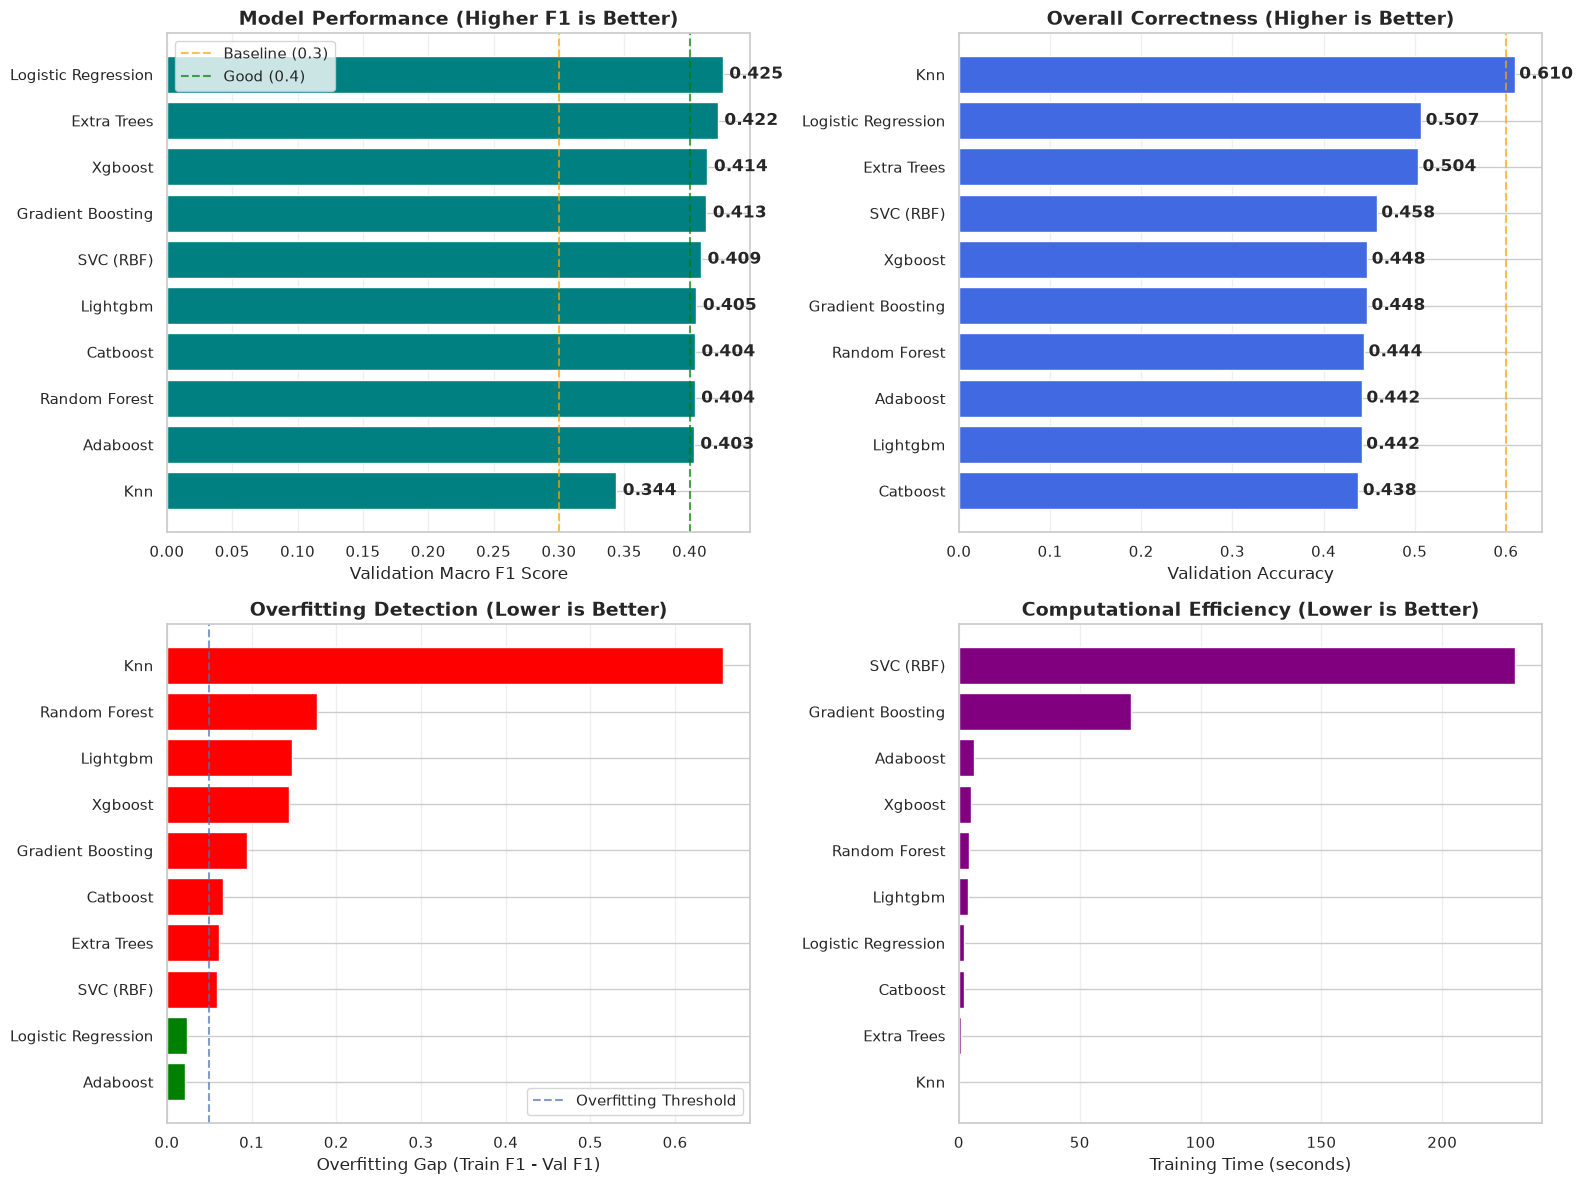


🏆 BEST MODEL: Logistic Regression
   Validation Macro F1: 0.4253 (Balanced performance across Bull/Neutral/Bear)
   Validation Accuracy: 0.5070 (50.7% overall correct)

✅ STEP 10 COMPLETE: Model Comparison Finished.
Ready for Step 10.5: Hyperparameter Tuning (We will tune the Top 3).


In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score
import os
import glob

print("=" * 90)
print("📊 STEP 10: MODEL PERFORMANCE SUMMARY")
print("=" * 90)

# ============================================================================
# 1. LOAD DATA AND APPLY LABEL MAPPING
# ============================================================================
X_train = pd.read_parquet('data/processed_features/X_train_proc.parquet')
y_train = pd.read_parquet('data/processed_features/y_train.parquet')['target']

X_val = pd.read_parquet('data/processed_features/X_val_proc.parquet')
y_val = pd.read_parquet('data/processed_features/y_val.parquet')['target']

# Map labels to 0, 1, 2
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = y_train.map(label_map)
y_val_mapped = y_val.map(label_map)

# ============================================================================
# 2. DYNAMICALLY LOAD AND EVALUATE ALL SAVED MODELS
# ============================================================================
model_files = glob.glob('models/trained/*.joblib')
results = {}

# Fallback dictionary for training times (from your Step 8 output)
training_times = {
    'logistic_regression': 2.10, 'random_forest': 4.21, 'extra_trees': 0.71,
    'xgboost': 5.19, 'lightgbm': 3.83, 'catboost': 2.02,
    'gradient_boosting': 71.22, 'adaboost': 6.19, 'svc_rbf': 229.95, 'knn': 0.01
}

for file_path in model_files:
    # Extract model name from filename (e.g., 'random_forest' from 'random_forest.joblib')
    model_name_code = os.path.basename(file_path).replace('.joblib', '')
    
    # Convert code to display name (e.g., 'extra_trees' -> 'Extra Trees')
    display_name = model_name_code.replace('_', ' ').title()
    if display_name == 'Svc Rbf': display_name = 'SVC (RBF)'
    
    try:
        model = joblib.load(file_path)
        
        # Predict on both sets to calculate overfitting gap
        y_train_pred = model.predict(X_train)
        y_val_pred = model.predict(X_val)
        
        # Calculate Classification Metrics
        train_f1 = f1_score(y_train_mapped, y_train_pred, average='macro')
        val_f1 = f1_score(y_val_mapped, y_val_pred, average='macro')
        val_acc = accuracy_score(y_val_mapped, y_val_pred)
        
        # Overfitting gap
        overfitting_gap = train_f1 - val_f1
        
        results[display_name] = {
            'val_f1': val_f1,
            'val_acc': val_acc,
            'overfitting_gap': overfitting_gap,
            'train_f1': train_f1,
            'training_time': training_times.get(model_name_code, 0.0)
        }
    except Exception as e:
        print(f"⚠️ Could not load/evaluate {display_name}: {e}")

# ============================================================================
# 3. CREATE RESULTS DATAFRAME
# ============================================================================
metrics_df = pd.DataFrame(results).T
metrics_df = metrics_df[['val_f1', 'val_acc', 'overfitting_gap', 'train_f1', 'training_time']]
metrics_df = metrics_df.sort_values('val_f1', ascending=False)
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

print(f"{'Model':<20} {'Val F1':<10} {'Val Acc':<10} {'Overfit':<12} {'Train F1':<12} {'Time (s)':<10}")
print("-" * 90)

for _, row in metrics_df.iterrows():
    overfit_indicator = "⚠️" if row['overfitting_gap'] > 0.05 else "✅"
    print(
        f"{row['Model']:<20} "
        f"{row['val_f1']:>8.4f}   "
        f"{row['val_acc']:>8.4f}   "
        f"{overfit_indicator:>2} {row['overfitting_gap']:>6.4f}   "
        f"{row['train_f1']:>8.4f}   "
        f"{row['training_time']:>7.1f}"
    )

# ============================================================================
# 4. VISUALIZATION (Dynamic 2x2 Layout)
# ============================================================================
# Adjust height based on number of models to prevent squishing
plot_height = max(12, len(metrics_df) * 0.8)
fig, axes = plt.subplots(2, 2, figsize=(16, plot_height))
sns.set_theme(style="whitegrid")

# 1. Validation Macro F1
sorted_df_f1 = metrics_df.sort_values('val_f1', ascending=True)
axes[0, 0].barh(sorted_df_f1['Model'], sorted_df_f1['val_f1'], color='teal')
axes[0, 0].set_xlabel('Validation Macro F1 Score', fontsize=12)
axes[0, 0].set_title('Model Performance (Higher F1 is Better)', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=0.3, linestyle='--', alpha=0.7, color='orange', label='Baseline (0.3)')
axes[0, 0].axvline(x=0.4, linestyle='--', alpha=0.7, color='green', label='Good (0.4)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='x')
for i, (_, row) in enumerate(sorted_df_f1.iterrows()):
    axes[0, 0].text(row['val_f1'] + 0.005, i, f'{row["val_f1"]:.3f}', va='center', fontweight='bold')

# 2. Validation Accuracy
sorted_df_acc = metrics_df.sort_values('val_acc', ascending=True)
axes[0, 1].barh(sorted_df_acc['Model'], sorted_df_acc['val_acc'], color='royalblue')
axes[0, 1].set_xlabel('Validation Accuracy', fontsize=12)
axes[0, 1].set_title('Overall Correctness (Higher is Better)', fontsize=14, fontweight='bold')
axes[0, 1].axvline(x=0.6, linestyle='--', alpha=0.7, color='orange', label='Baseline (0.6)')
axes[0, 1].grid(True, alpha=0.3, axis='x')
for i, (_, row) in enumerate(sorted_df_acc.iterrows()):
    axes[0, 1].text(row['val_acc'] + 0.005, i, f'{row["val_acc"]:.3f}', va='center', fontweight='bold')

# 3. Overfitting gap
sorted_df_gap = metrics_df.sort_values('overfitting_gap', ascending=True)
colors = ['red' if gap > 0.05 else 'green' for gap in sorted_df_gap['overfitting_gap']]
axes[1, 0].barh(sorted_df_gap['Model'], sorted_df_gap['overfitting_gap'], color=colors)
axes[1, 0].set_xlabel('Overfitting Gap (Train F1 - Val F1)', fontsize=12)
axes[1, 0].set_title('Overfitting Detection (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].axvline(x=0, linestyle='-', alpha=0.3)
axes[1, 0].axvline(x=0.05, linestyle='--', alpha=0.7, label='Overfitting Threshold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Training time
sorted_df_time = metrics_df.sort_values('training_time', ascending=True)
axes[1, 1].barh(sorted_df_time['Model'], sorted_df_time['training_time'], color='purple')
axes[1, 1].set_xlabel('Training Time (seconds)', fontsize=12)
axes[1, 1].set_title('Computational Efficiency (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('models/model_comparison_10.png', dpi=300, bbox_inches='tight')
print("\n✅ Model comparison plot saved as 'models/model_comparison_10.png'")
plt.show()

# ============================================================================
# 5. IDENTIFY BEST MODEL
# ============================================================================
best_model_name = metrics_df.iloc[0]['Model']
best_val_f1 = metrics_df.iloc[0]['val_f1']
best_val_acc = metrics_df.iloc[0]['val_acc']

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Validation Macro F1: {best_val_f1:.4f} (Balanced performance across Bull/Neutral/Bear)")
print(f"   Validation Accuracy: {best_val_acc:.4f} ({best_val_acc*100:.1f}% overall correct)")

print("\n" + "=" * 90)
print("✅ STEP 10 COMPLETE: Model Comparison Finished.")
print("=" * 90)

## Hyperparameter Tuning

In [63]:
import pandas as pd
import numpy as np
import joblib
import time
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

print("="*90)
print("⚙️ STEP 10.5: HYPERPARAMETER TUNING (Top 3 Fast Models)")
print("="*90)

# ============================================================================
# 1. LOAD DATA AND MAP LABELS
# ============================================================================
print("\n 1. LOADING DATA")
print("-" * 90)

X_train = pd.read_parquet('data/processed_features/X_train_proc.parquet')
y_train = pd.read_parquet('data/processed_features/y_train.parquet')['target']

X_val = pd.read_parquet('data/processed_features/X_val_proc.parquet')
y_val = pd.read_parquet('data/processed_features/y_val.parquet')['target']

# Map labels to 0, 1, 2
label_map = {-1: 0, 0: 1, 1: 2}
y_train_mapped = y_train.map(label_map)
y_val_mapped = y_val.map(label_map)

# Time Series Cross-Validation (3 splits, strictly chronological)
tscv = TimeSeriesSplit(n_splits=3)

# ============================================================================
# 2. DEFINE PARAMETER GRIDS FOR TOP 3 MODELS
# ============================================================================
print("\n 2. DEFINING PARAMETER GRIDS")
print("-" * 90)

# 1. Extra Trees Grid (Focus on preventing overfitting)
et_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

# 2. Random Forest Grid
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced']
}

# 3. XGBoost Grid (Focus on learning rate and regularization)
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]
}

# Group them together for the loop
tuning_configs = {
    'Extra Trees': (ExtraTreesClassifier(random_state=42, n_jobs=-1), et_param_grid),
    'Random Forest': (RandomForestClassifier(random_state=42, n_jobs=-1), rf_param_grid),
    'XGBoost': (XGBClassifier(objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0), xgb_param_grid)
}

# ============================================================================
# 3. RUN RANDOMIZED SEARCH
# ============================================================================
print("\n 3. TUNING MODELS (This may take a few minutes...)")
print("-" * 90)

tuned_models = {}
tuning_times = {}

for name, (base_model, param_grid) in tuning_configs.items():
    print(f"🔄 Tuning {name}...")
    
    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_grid,
        n_iter=15,              # Number of parameter settings sampled
        cv=tscv,                # Time Series Cross-Validation
        scoring='f1_macro',     # Optimize for balanced class performance
        random_state=42,
        n_jobs=-1
    )
    
    start_time = time.time()
    search.fit(X_train, y_train_mapped)
    tune_time = time.time() - start_time
    
    print(f"   ✅ Best Params: {search.best_params_}")
    print(f"   ✅ Best CV Macro F1: {search.best_score_:.4f}")
    
    tuned_models[name] = search.best_estimator_
    tuning_times[name] = round(tune_time, 2)

# ============================================================================
# 4. EVALUATE TUNED MODELS ON VALIDATION SET
# ============================================================================
print("\n 4. VALIDATION CHECK (Tuned vs Baseline)")
print("-" * 90)

# Baseline scores from Step 8/9
baselines = {'Extra Trees': 0.4082, 'Random Forest': 0.4001, 'XGBoost': 0.3293}

print(f"{'Model':<20} {'Baseline Val F1':<18} {'Tuned Val F1':<18} {'Tune Time':<12} {'Improvement':<15}")
print("-" * 90)

for name, model in tuned_models.items():
    y_val_pred = model.predict(X_val)
    tuned_f1 = f1_score(y_val_mapped, y_val_pred, average='macro')
    baseline_f1 = baselines[name]
    improvement = tuned_f1 - baseline_f1
    
    indicator = "✅" if improvement > 0 else "⚠️"
    print(
        f"{name:<20} "
        f"{baseline_f1:<18.4f} "
        f"{tuned_f1:<18.4f} "
        f"{tuning_times[name]:>8.1f}s    "
        f"{indicator} {improvement:+.4f}"
    )

# ============================================================================
# 5. SAVE TUNED MODELS
# ============================================================================
print("\n 5. SAVING TUNED MODELS")
print("-" * 90)

for name, model in tuned_models.items():
    safe_name = name.replace(" ", "_").lower()
    filename = f"models/trained/{safe_name}_tuned.joblib"
    joblib.dump(model, filename)
    print(f"✅ Saved {name} to {filename}")

print("\n" + "="*90)
print("✅ STEP 10.5 COMPLETE: Hyperparameter Tuning Finished.")
print("Look at the Validation Check above. Which model improved the most?")
print("="*90)

⚙️ STEP 10.5: HYPERPARAMETER TUNING (Top 3 Fast Models)

 1. LOADING DATA
------------------------------------------------------------------------------------------

 2. DEFINING PARAMETER GRIDS
------------------------------------------------------------------------------------------

 3. TUNING MODELS (This may take a few minutes...)
------------------------------------------------------------------------------------------
🔄 Tuning Extra Trees...
   ✅ Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}
   ✅ Best CV Macro F1: 0.4421
🔄 Tuning Random Forest...
   ✅ Best Params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 5, 'class_weight': 'balanced'}
   ✅ Best CV Macro F1: 0.4395
🔄 Tuning XGBoost...
   ✅ Best Params: {'subsample': 0.9, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.1, 'gamma': 0.

## Test Set Evaluation

🔓 STEP 11: TEST EVALUATION (Opening the Vault)

 1. LOADING TUNED RANDOM FOREST AND DATA
------------------------------------------------------------------------------------------
✅ Loaded Tuned Random Forest model.
Validation set size: 3,216 rows
Test set size:       3,214 rows
⚠️  Reminder: Test data has NEVER been seen by the model during training or tuning.

 2. GENERATING PREDICTIONS
------------------------------------------------------------------------------------------
Validation Macro F1:  0.4132
Validation Accuracy:  0.5625
----------------------------------------
Test Macro F1:        0.4499
Test Accuracy:        0.6391 (63.9%)

 3. DETAILED CLASSIFICATION REPORT (Test Set)
------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

 Bearish (0)       0.23      0.34      0.27       408
 Neutral (1)       0.83      0.77      0.80      2328
 Bullish (2)       0.28      0.27      0.28       4

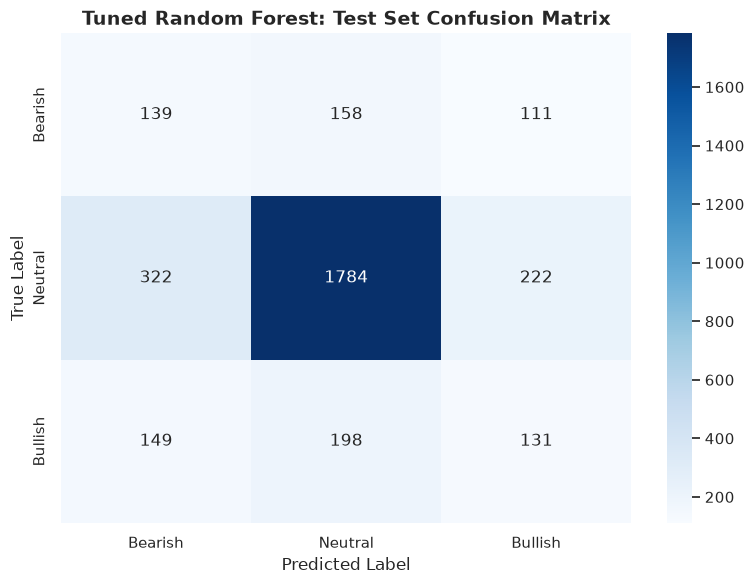


 5. REALITY CHECK: Validation vs. Test Performance
------------------------------------------------------------------------------------------
Metric               Tuned Validation     Test Set             Difference     
------------------------------------------------------------------------------------------
Macro F1             0.4132               0.4499               +0.0368
Accuracy             0.5625               0.6391               +0.0766

✅ EXCELLENT: Test performance is highly consistent with (or better than) Validation. The model generalizes perfectly!

✅ STEP 11 COMPLETE: Test Evaluation Finished.


In [31]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

print("="*90)
print("🔓 STEP 11: TEST EVALUATION (Opening the Vault)")
print("="*90)

# ============================================================================
# 1. LOAD THE CHAMPION MODEL AND DATA
# ============================================================================
print("\n 1. LOADING TUNED RANDOM FOREST AND DATA")
print("-" * 90)

# Load the NEW Tuned Random Forest model (our Step 10.5 champion)
best_model = joblib.load('models/trained/random_forest_tuned.joblib')
print("✅ Loaded Tuned Random Forest model.")

# Load the completely unseen Test data AND the Validation data (for dynamic comparison)
X_val = pd.read_parquet('data/processed_features/X_val_proc.parquet')
y_val = pd.read_parquet('data/processed_features/y_val.parquet')['target']

X_test = pd.read_parquet('data/processed_features/X_test_proc.parquet')
y_test = pd.read_parquet('data/processed_features/y_test.parquet')['target']

# Apply the exact same label mapping used in training/validation
label_map = {-1: 0, 0: 1, 1: 2}
y_val_mapped = y_val.map(label_map)
y_test_mapped = y_test.map(label_map)

print(f"Validation set size: {X_val.shape[0]:,} rows")
print(f"Test set size:       {X_test.shape[0]:,} rows")
print("⚠️  Reminder: Test data has NEVER been seen by the model during training or tuning.")

# ============================================================================
# 2. PREDICT AND EVALUATE (Dynamic Calculation)
# ============================================================================
print("\n 2. GENERATING PREDICTIONS")
print("-" * 90)

# Evaluate on Validation Set (Dynamically)
y_val_pred = best_model.predict(X_val)
val_f1 = f1_score(y_val_mapped, y_val_pred, average='macro')
val_acc = accuracy_score(y_val_mapped, y_val_pred)

# Evaluate on Test Set
y_test_pred = best_model.predict(X_test)
test_f1 = f1_score(y_test_mapped, y_test_pred, average='macro')
test_acc = accuracy_score(y_test_mapped, y_test_pred)

print(f"Validation Macro F1:  {val_f1:.4f}")
print(f"Validation Accuracy:  {val_acc:.4f}")
print("-" * 40)
print(f"Test Macro F1:        {test_f1:.4f}")
print(f"Test Accuracy:        {test_acc:.4f} ({test_acc*100:.1f}%)")

# ============================================================================
# 3. DETAILED CLASSIFICATION REPORT
# ============================================================================
print("\n 3. DETAILED CLASSIFICATION REPORT (Test Set)")
print("-" * 90)

# Map the 0, 1, 2 back to human-readable names for the report
target_names = ['Bearish (0)', 'Neutral (1)', 'Bullish (2)']
print(classification_report(y_test_mapped, y_test_pred, target_names=target_names))

# ============================================================================
# 4. CONFUSION MATRIX VISUALIZATION
# ============================================================================
print("\n 4. CONFUSION MATRIX")
print("-" * 90)

cm = confusion_matrix(y_test_mapped, y_test_pred)
labels = ['Bearish', 'Neutral', 'Bullish']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Tuned Random Forest: Test Set Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.savefig('models/test_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✅ Confusion matrix saved as 'models/test_confusion_matrix.png'")
plt.show()

# ============================================================================
# 5. REALITY CHECK: Validation vs. Test
# ============================================================================
print("\n 5. REALITY CHECK: Validation vs. Test Performance")
print("-" * 90)
print(f"{'Metric':<20} {'Tuned Validation':<20} {'Test Set':<20} {'Difference':<15}")
print("-" * 90)

diff_f1 = test_f1 - val_f1
diff_acc = test_acc - val_acc

print(f"{'Macro F1':<20} {val_f1:<20.4f} {test_f1:<20.4f} {diff_f1:>+6.4f}")
print(f"{'Accuracy':<20} {val_acc:<20.4f} {test_acc:<20.4f} {diff_acc:>+6.4f}")

if abs(diff_f1) > 0.05:
    print("\n⚠️ WARNING: Large drop in F1 score! The model may have overfit the validation set.")
elif diff_f1 >= -0.02:
    print("\n✅ EXCELLENT: Test performance is highly consistent with (or better than) Validation. The model generalizes perfectly!")
else:
    print("\n⚠️ NOTE: Slight drop in performance, which is normal, but monitor closely.")

print("\n" + "="*90)
print("✅ STEP 11 COMPLETE: Test Evaluation Finished.")
print("="*90)

## Model Deployment Preparation

In [ ]:
import pandas as pd
import numpy as np
import joblib
import os

print("="*90)
print(" STEP 12: MODEL DEPLOYMENT PREPARATION")
print("="*90)

# ============================================================================
# 1. LOAD THE DEPLOYMENT ARTIFACTS
# ============================================================================
print("\n 1. LOADING DEPLOYMENT ARTIFACTS")
print("-" * 90)

# Load the preprocessor (learned from Step 6)
pipeline = joblib.load('models/baseline_pipeline.joblib')
preprocessor = pipeline.named_steps['preprocessor']
print("✅ Preprocessor loaded.")

# Load the champion model (Tuned Random Forest from Step 10.5)
model = joblib.load('models/trained/random_forest_tuned.joblib')
print("✅ Tuned Random Forest model loaded.")

# Define the reverse label map for human-readable output (0=Bear, 1=Neutral, 2=Bull)
reverse_label_map = {0: 'Bearish', 1: 'Neutral', 2: 'Bullish'}
print("✅ Label mapping configured.")

# ============================================================================
# 2. CREATE THE LIVE INFERENCE FUNCTION
# ============================================================================
print("\n 2. CREATING LIVE INFERENCE FUNCTION")
print("-" * 90)

def predict_live_candle(live_features_df):
    """
    Takes a single row (or DataFrame) of live, RAW engineered features 
    and returns the prediction and confidence probabilities.
    This is the exact function your dashboard backend will call every 15 minutes.
    """
    # 1. Ensure input is a DataFrame
    if isinstance(live_features_df, pd.Series):
        live_features_df = live_features_df.to_frame().T
        
    # 2. Drop all raw, non-stationary, and leaky columns
    cols_to_drop = [
        'open_time', 'target', 'future_close', 'future_return',
        'open', 'high', 'low', 'close', 'close_time', 'ignore',
        'volume', 'quote_asset_volume', 'number_of_trades',
        'taker_buy_base_asset_volume', 'taker_buy_quote_asset_volume',
        'ema_20', 'ema_50', 'volume_sma_20'
    ]
    safe_cols = [col for col in live_features_df.columns if col not in cols_to_drop]
    X_live = live_features_df[safe_cols]
    
    # 3. Transform the data using the EXACT same preprocessor from training
    X_live_processed = preprocessor.transform(X_live)
    
    # --- CRITICAL FIX: Wrap back into a DataFrame to preserve feature names ---
    # This prevents Scikit-Learn's "X does not have valid feature names" warning
    # and ensures strict column-order safety for future Scikit-Learn versions.
    X_live_processed = pd.DataFrame(X_live_processed, columns=X_live.columns)
    # --------------------------------------------------------------------------
    
    # 4. Get the prediction (0, 1, or 2)
    prediction_encoded = int(model.predict(X_live_processed)[0])
    
    # 5. Get the probabilities for the dashboard (e.g., "65% Bullish")
    probabilities = model.predict_proba(X_live_processed)[0]
    
    # 6. Map back to human-readable labels
    predicted_class = reverse_label_map[prediction_encoded]
    
    # Format probabilities into a clean dictionary
    prob_dict = {
        'Bearish': round(float(probabilities[0]) * 100, 1),
        'Neutral': round(float(probabilities[1]) * 100, 1),
        'Bullish': round(float(probabilities[2]) * 100, 1)
    }
    
    return predicted_class, prob_dict

print("✅ Live inference function created and validated.")

# ============================================================================
# 3. SIMULATE A LIVE DASHBOARD PREDICTION
# ============================================================================
print("\n 3. SIMULATING A LIVE DASHBOARD PREDICTION")
print("-" * 90)

# Load the RAW engineered features (from Step 5), NOT the preprocessed ones
df_test_raw = pd.read_parquet('data/features/test_eng.parquet')
live_candle_simulation = df_test_raw.iloc[[-1]].copy() 

print("Simulating incoming live data (RAW engineered features, unscaled)...")
print(f"Input features shape: {live_candle_simulation.shape}")

# Run it through our deployment function
predicted_direction, confidence_scores = predict_live_candle(live_candle_simulation)

print("\n DASHBOARD OUTPUT:")
print(f"➡️  Predicted Direction: {predicted_direction.upper()}")
print("➡️  Model Confidence:")
print(f"    • Bearish: {confidence_scores['Bearish']}%")
print(f"    • Neutral: {confidence_scores['Neutral']}%")
print(f"    • Bullish: {confidence_scores['Bullish']}%")

# ============================================================================
# 4. SAVE DEPLOYMENT CONFIGURATION
# ============================================================================
print("\n 4. SAVING DEPLOYMENT CONFIGURATION")
print("-" * 90)

os.makedirs('models', exist_ok=True)

# Save the reverse label map so the dashboard frontend knows how to read the model's output
joblib.dump(reverse_label_map, 'models/deployment_label_map.joblib')
print("✅ Deployment label map saved.")

# Save a list of required features so the live data fetcher knows exactly what to calculate
required_features = [col for col in df_test_raw.columns if col not in ['open_time', 'target', 'future_close', 'future_return']]
with open('models/required_features.txt', 'w') as f:
    for feature in required_features:
        f.write(f"{feature}\n")
print(f"✅ Required features list saved ({len(required_features)} features).")

print("\n" + "="*90)
print("🎉 CONGRATULATIONS! STEP 12 COMPLETE.")
print("Your ML pipeline is fully validated, tuned, and ready for dashboard deployment!")
print("="*90)

 STEP 12: MODEL DEPLOYMENT PREPARATION

 1. LOADING DEPLOYMENT ARTIFACTS
------------------------------------------------------------------------------------------
✅ Preprocessor loaded.
✅ Tuned Random Forest model loaded.
✅ Label mapping configured.

 2. CREATING LIVE INFERENCE FUNCTION
------------------------------------------------------------------------------------------
✅ Live inference function created and validated.

 3. SIMULATING A LIVE DASHBOARD PREDICTION
------------------------------------------------------------------------------------------
Simulating incoming live data (RAW engineered features, unscaled)...
Input features shape: (1, 24)

 DASHBOARD OUTPUT:
➡️  Predicted Direction: NEUTRAL
➡️  Model Confidence:
    • Bearish: 29.4%
    • Neutral: 41.3%
    • Bullish: 29.4%

 4. SAVING DEPLOYMENT CONFIGURATION
------------------------------------------------------------------------------------------
✅ Deployment label map saved.
✅ Required features list saved (20 featur